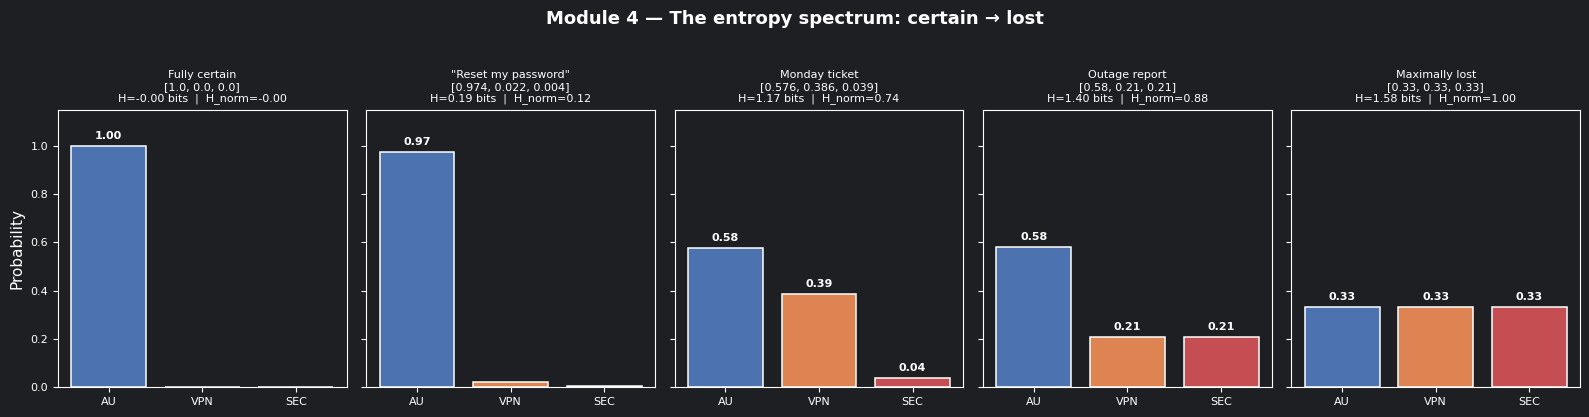

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

labels = ["account_unlock", "vpn_issue", "security_incident"]
colors = ["#4C72B0", "#DD8452", "#C44E52"]

def entropy(p):
    p = np.array(p)
    p = p[p > 0]           # avoid log(0)
    return -np.sum(p * np.log2(p))

def h_norm(p, n=3):
    return entropy(p) / np.log2(n)

# Five distributions along the spectrum
distributions = [
    ([1.00, 0.00, 0.00], "Fully certain\n[1.0, 0.0, 0.0]"),
    ([0.974, 0.022, 0.004], '"Reset my password"\n[0.974, 0.022, 0.004]'),
    ([0.576, 0.386, 0.039], "Monday ticket\n[0.576, 0.386, 0.039]"),
    ([0.58,  0.21,  0.21 ], "Outage report\n[0.58, 0.21, 0.21]"),
    ([0.333, 0.333, 0.334], "Maximally lost\n[0.33, 0.33, 0.33]"),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, (dist, title) in zip(axes, distributions):
    h  = entropy(dist)
    hn = h_norm(dist)
    bars = ax.bar(["AU", "VPN", "SEC"], dist, color=colors,
                  edgecolor="white", linewidth=1.1)
    for bar, p in zip(bars, dist):
        if p > 0.03:
            ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
                    f"{p:.2f}", ha="center", va="bottom", fontsize=8,
                    fontweight="bold")
    ax.set_title(f"{title}\nH={h:.2f} bits  |  H_norm={hn:.2f}",
                 fontsize=8, pad=6)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("Probability", fontsize=11)
fig.suptitle("Module 4 — The entropy spectrum: certain → lost",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("m4_fig1_entropy_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

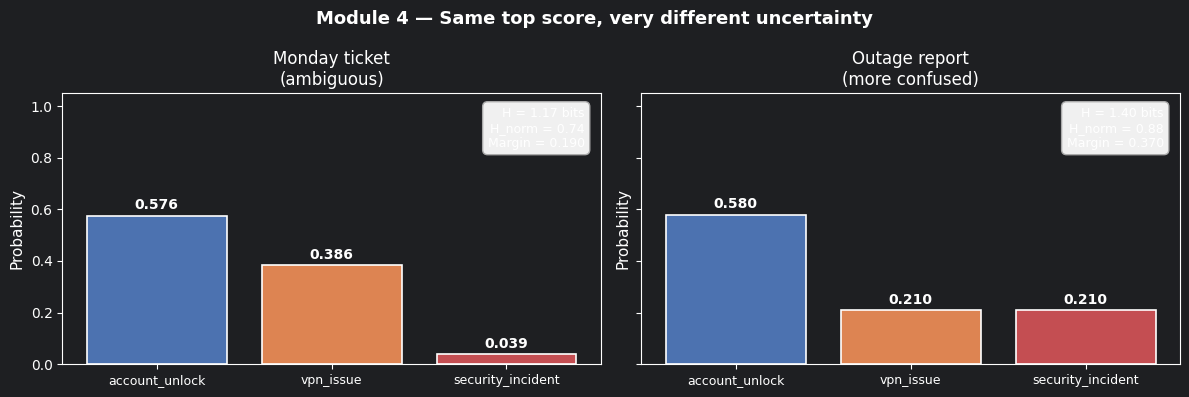

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

tickets = [
    {
        "probs": [0.576, 0.386, 0.039],
        "title": "Monday ticket\n(ambiguous)",
    },
    {
        "probs": [0.58, 0.21, 0.21],
        "title": "Outage report\n(more confused)",
    },
]

for ax, ticket in zip(axes, tickets):
    p  = ticket["probs"]
    h  = entropy(p)
    hn = h_norm(p)
    margin = p[0] - p[1]

    bars = ax.bar(labels, p, color=colors, edgecolor="white", linewidth=1.2)
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width() / 2, prob + 0.012,
                f"{prob:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    # Entropy annotation box
    ax.text(0.97, 0.95,
            f"H = {h:.2f} bits\nH_norm = {hn:.2f}\nMargin = {margin:.3f}",
            transform=ax.transAxes, fontsize=9, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0",
                      edgecolor="#aaaaaa"))

    ax.set_ylim(0, 1.05)
    ax.set_title(ticket["title"], fontsize=12)
    ax.set_ylabel("Probability", fontsize=11)
    ax.tick_params(axis="x", labelsize=9)

fig.suptitle("Module 4 — Same top score, very different uncertainty",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("m4_fig2_monday_vs_outage.png", dpi=150)
plt.show()

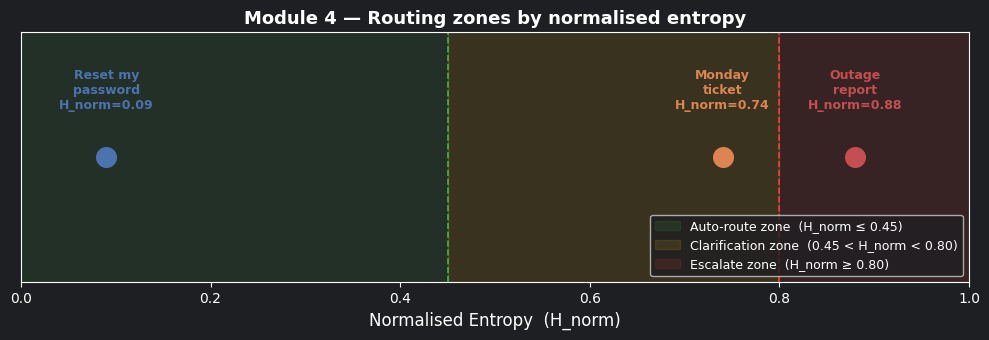

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.5))

# ── Routing zones ────────────────────────────────────────────────────────────
ax.axvspan(0.00, 0.45, alpha=0.12, color="#4CAF50", label="Auto-route zone  (H_norm ≤ 0.45)")
ax.axvspan(0.45, 0.80, alpha=0.12, color="#FFC107", label="Clarification zone  (0.45 < H_norm < 0.80)")
ax.axvspan(0.80, 1.00, alpha=0.12, color="#F44336", label="Escalate zone  (H_norm ≥ 0.80)")

ax.axvline(0.45, color="#4CAF50", linestyle="--", linewidth=1.2)
ax.axvline(0.80, color="#F44336", linestyle="--", linewidth=1.2)

# ── Ticket markers ────────────────────────────────────────────────────────────
ticket_points = [
    (0.09, "Reset my\npassword", "#4C72B0"),
    (0.74, "Monday\nticket",     "#DD8452"),
    (0.88, "Outage\nreport",     "#C44E52"),
]

for hn, name, color in ticket_points:
    ax.scatter(hn, 0.5, s=200, color=color, zorder=5)
    ax.text(hn, 0.68, f"{name}\nH_norm={hn}",
            ha="center", va="bottom", fontsize=9,
            fontweight="bold", color=color)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Normalised Entropy  (H_norm)", fontsize=12)
ax.set_yticks([])
ax.set_title("Module 4 — Routing zones by normalised entropy",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("m4_fig3_hnorm_routing_zones.png", dpi=150)
plt.show()

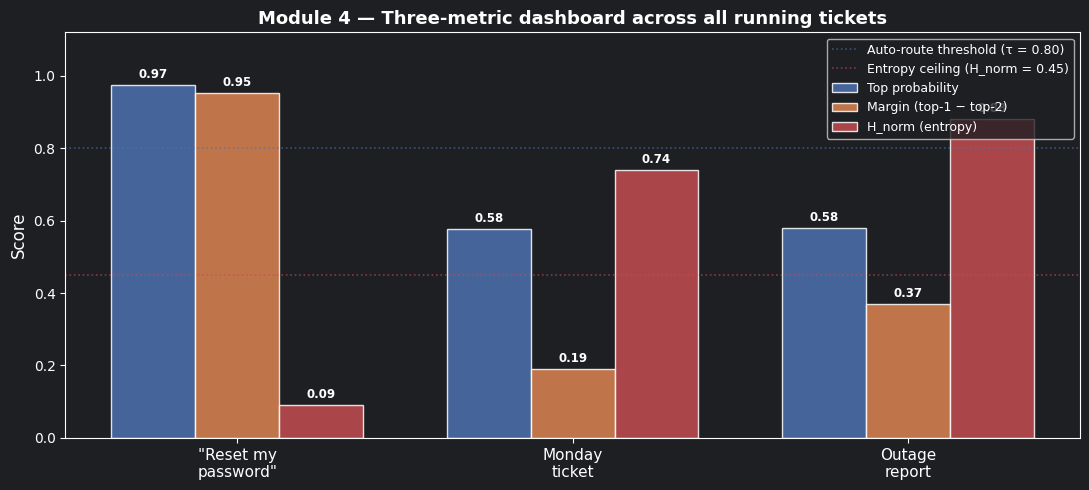

In [4]:
ticket_names = ['"Reset my\npassword"', 'Monday\nticket', 'Outage\nreport']

top_probs = [0.974, 0.576, 0.580]
margins   = [0.952, 0.190, 0.370]
h_norms   = [0.09,  0.74,  0.88 ]

x     = np.arange(len(ticket_names))
width = 0.25
metric_colors = ["#4C72B0", "#DD8452", "#C44E52"]

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width, top_probs, width, label="Top probability",
            color=metric_colors[0], alpha=0.85, edgecolor="white")
b2 = ax.bar(x,          margins,   width, label="Margin (top-1 − top-2)",
            color=metric_colors[1], alpha=0.85, edgecolor="white")
b3 = ax.bar(x + width,  h_norms,   width, label="H_norm (entropy)",
            color=metric_colors[2], alpha=0.85, edgecolor="white")

# Annotate
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="bold")

# Threshold lines
ax.axhline(0.80, color="#4C72B0", linestyle=":", linewidth=1.2,
           alpha=0.6, label="Auto-route threshold (τ = 0.80)")
ax.axhline(0.45, color="#C44E52", linestyle=":", linewidth=1.2,
           alpha=0.6, label="Entropy ceiling (H_norm = 0.45)")

ax.set_xticks(x)
ax.set_xticklabels(ticket_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Module 4 — Three-metric dashboard across all running tickets",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("m4_fig4_three_metric_dashboard.png", dpi=150)
plt.show()

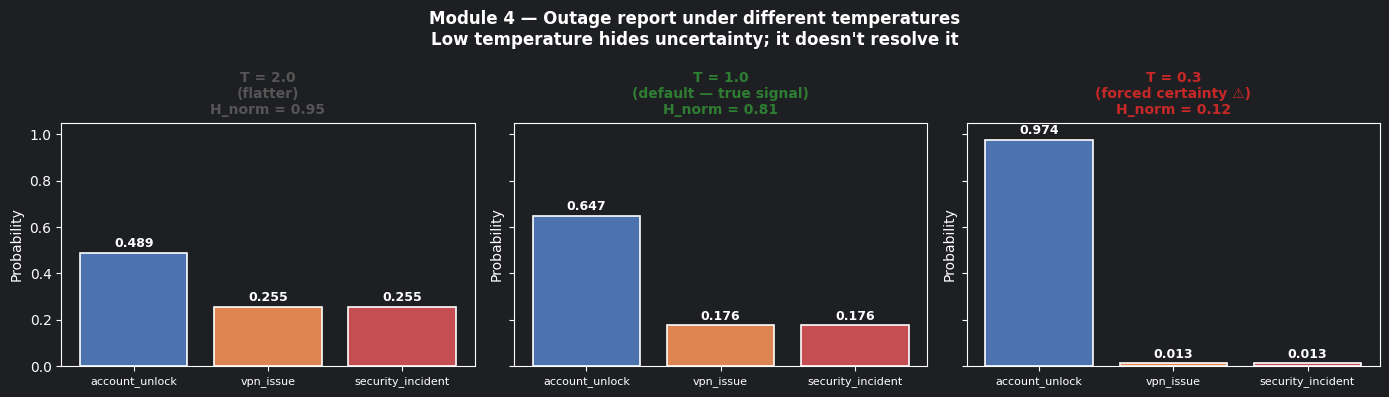

In [5]:
from matplotlib.patches import FancyArrowPatch

def softmax(z, T=1.0):
    z_shifted = z - np.max(z)
    e = np.exp(z_shifted / T)
    return e / e.sum()

# Outage report probabilities back-calculated to approximate logits
# [0.58, 0.21, 0.21] ≈ logits [2.1, 0.8, 0.8]
outage_logits = np.array([2.1, 0.8, 0.8])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
temps = [2.0, 1.0, 0.3]
titles = ["T = 2.0\n(flatter)", "T = 1.0\n(default — true signal)", "T = 0.3\n(forced certainty ⚠️)"]
title_colors = ["#555555", "#2E7D32", "#C62828"]

for ax, T, title, tc in zip(axes, temps, titles, title_colors):
    p  = softmax(outage_logits, T=T)
    h  = entropy(p)
    hn = h_norm(p)
    bars = ax.bar(labels, p, color=colors, edgecolor="white", linewidth=1.2)
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width() / 2, prob + 0.012,
                f"{prob:.3f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
    ax.set_title(f"{title}\nH_norm = {hn:.2f}", fontsize=10, color=tc,
                 fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability", fontsize=10)
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle(
    "Module 4 — Outage report under different temperatures\n"
    "Low temperature hides uncertainty; it doesn't resolve it",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("m4_fig5_temperature_hides_entropy.png", dpi=150)
plt.show()